<a href="https://colab.research.google.com/github/rheopy/rheolite/blob/main/content/walkthrough/tc_vs_hb_carbopol_pg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🥊 TC vs Herschel–Bulkley on a Carbopol flow curve

*Reproduces the [rheofit walkthrough case study](https://rheofit.readthedocs.io/en/latest/walkthrough.html)
in your browser: **2% Carbopol Ultrez 21 in propylene glycol**, a jammed microgel in a viscous
continuous phase — fitted head-to-head with the **TC (three-component)** model and **Herschel–Bulkley**.
Watch TC separate the physics term by term while HB settles for a compromise exponent.*

**Run each cell in order** (▶). The first cell installs `rheofit` in your browser — no server involved.

In [8]:
%pip install -q rheofit rheopy-rheodata


Note: you may need to restart the kernel to use updated packages.


c:\Users\caggioni.m\rheolite\.venv\Scripts\python.exe: No module named pip


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import rheodata
import rheofit

rheofit_version = getattr(rheofit, "__version__", "installed")
rheodata_version = getattr(rheodata, "__version__", "installed")
print(f"rheofit {rheofit_version} | rheodata {rheodata_version}")

rheofit 1.1.0 | rheodata installed


## 🧪 The dataset

A single equilibrium flow sweep of **2% Carbopol Ultrez 21
dispersed in propylene glycol** — 61 points, shear rates 10⁻³–10³ s⁻¹, 20 °C,
concentric-cylinder geometry. The dataset comes from the [rheodata](https://github.com/rheopy/rheodata) library (`caggioni_pg_carbopol_2pct`) — no file download needed.

In [18]:
flow_curve = rheodata.to_rheofit(
    "caggioni_pg_carbopol_2pct",
    "carbopol_2pct",
)
flow_curve

,Shear rate / 1/s,Stress / Pa
0,0.000998,21.2851
1,0.001258,21.4806
2,0.001585,21.7349
3,0.001994,22.0484
4,0.002510,21.6008
...,...,...
56,398.960000,728.4120
57,501.283000,867.9330
58,631.034000,1041.5600
59,794.537000,1259.6600


In [20]:
measurement_temperature_celsius = rheodata.load(
    "caggioni_pg_carbopol_2pct"
).meta["measurement"]["temperature_C"]

measurement_temperature_celsius

20

## 🥊 The showdown: TC vs Herschel–Bulkley

Carbopol is a jammed microgel — a soft-particle glass — and propylene glycol is a
*viscous* continuous phase. That combination is exactly where the TC (three-component)
model earns its keep over Herschel–Bulkley: HB has no explicit viscous term, so its
exponent drifts into a compromise. Both fits run at `effort="thorough"`, fixed seed —
reproducible bit-for-bit.

In [22]:
df=flow_curve
def fit_table(name, label):
    r = rheofit.fit(df, name, effort="thorough", seed=0)
    print(f"--- {label} ---")
    print("RedChi2 = %.3e, cond = %.2g" % (r["redchi"], r["cond"]))
    print("%-14s %12s %12s %10s" % ("param", "value", "stderr", "rel err"))
    for k, v in r["params"].items():
        re = 100 * v["stderr"] / v["value"]
        print("%-14s %12.5g %12.3g %9.2f%%" % (k, v["value"], v["stderr"], re))
    print()
    return r

r_tc = fit_table("tc", "TC")
r_hb = fit_table("herschel_bulkley", "Herschel-Bulkley")
print("TC wins by %.1fx in RedChi2" % (r_hb["redchi"] / r_tc["redchi"]))

--- TC ---
RedChi2 = 6.018e-04, cond = 11
param                 value       stderr    rel err
sigma_y              20.823        0.127      0.61%
gamma_dot_c         0.95342       0.0283      2.96%
eta_bg              0.71503       0.0203      2.84%

--- Herschel-Bulkley ---
RedChi2 = 3.651e-03, cond = 6.3
param                 value       stderr    rel err
sigma_y              22.025        0.334      1.51%
K                    19.202        0.649      3.38%
n                   0.59508      0.00746      1.25%

TC wins by 6.1x in RedChi2


## 📉 What the numbers say

| model | RedChi² | parameters |
|---|---|---|
| **TC** | **6.018e-04** | σ_y = 20.8 Pa, γ̇_c = 0.95 s⁻¹, η_bg = 0.715 Pa·s |
| Herschel–Bulkley | 3.651e-03 | σ_y = 22.0 Pa, K = 19.2 Pa·sⁿ, n = 0.595 |

TC wins by a factor of ~6 in relative-weighted error, and every TC
parameter is tightly identified (relative errors 0.6–3.0%,
no warnings). But the number is the least interesting part — look at *where* HB fails,
in the residual panel of the plot below.

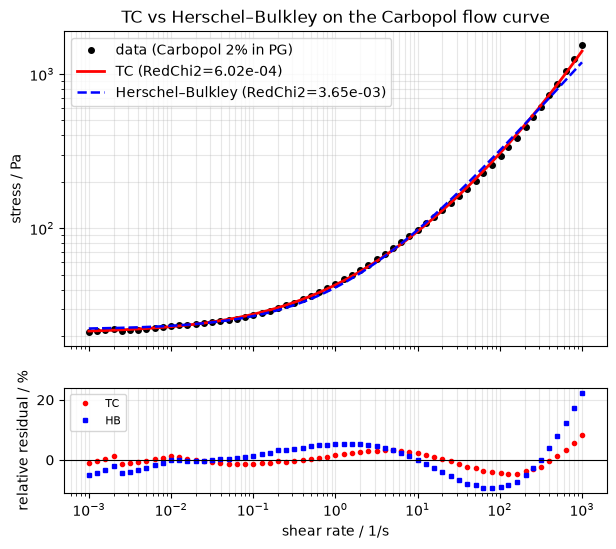

In [23]:
fig, (ax_stress, ax_residual) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax_stress.loglog(
    shear_rate,
    stress,
    "ko",
    ms=4,
    label="data (Carbopol 2% in PG)",
)
ax_stress.loglog(
    shear_rate_grid,
    tc_stress_fit,
    "r-",
    lw=2,
    label=f"TC (RedChi2={tc_fit['redchi']:.2e})",
)
ax_stress.loglog(
    shear_rate_grid,
    herschel_bulkley_stress_fit,
    "b--",
    lw=1.8,
    label=f"Herschel–Bulkley (RedChi2={herschel_bulkley_fit['redchi']:.2e})",
)
ax_stress.set_ylabel("stress / Pa")
ax_stress.set_title("TC vs Herschel–Bulkley on the Carbopol flow curve")
ax_stress.legend()
ax_stress.grid(True, which="both", alpha=0.3)

relative_residual_tc_pct = 100 * (
    stress - tc_stress(shear_rate, tc_parameters)
) / stress
relative_residual_herschel_bulkley_pct = 100 * (
    stress - herschel_bulkley_stress(shear_rate, herschel_bulkley_parameters)
) / stress

ax_residual.semilogx(
    shear_rate,
    relative_residual_tc_pct,
    "ro",
    ms=3,
    label="TC",
)
ax_residual.semilogx(
    shear_rate,
    relative_residual_herschel_bulkley_pct,
    "bs",
    ms=3,
    label="HB",
)
ax_residual.axhline(0, color="k", lw=0.8)
ax_residual.set_xlabel("shear rate / 1/s")
ax_residual.set_ylabel("relative residual / %")
ax_residual.legend(fontsize=8)
ax_residual.grid(True, which="both", alpha=0.3)

HB's residuals swing in a systematic S-shape (±10–20%) while TC's stay flat (±5%).
A single power-law exponent *n* ≈ 0.6 is trying to do two jobs at once — mimic the √γ̇
plastic rise at intermediate rates *and* the linear viscous rise at high rates — and it
does neither exactly. This is the physics the walkthrough argues: the HB exponent is an
empirical compromise that drifts with the continuous-phase viscosity, while TC gives
each dissipation mechanism its own parameter.

## 🔬 Reading the TC fit: three mechanisms, one curve

$$\sigma = \underbrace{\sigma_y}_{\text{elastic}} +
\underbrace{\sigma_y\sqrt{\dot\gamma/\dot\gamma_c}}_{\text{plastic}} +
\underbrace{\eta_{bg}\,\dot\gamma}_{\text{viscous}}$$

Fitted to the data, each term draws its own curve — and each curve means something.

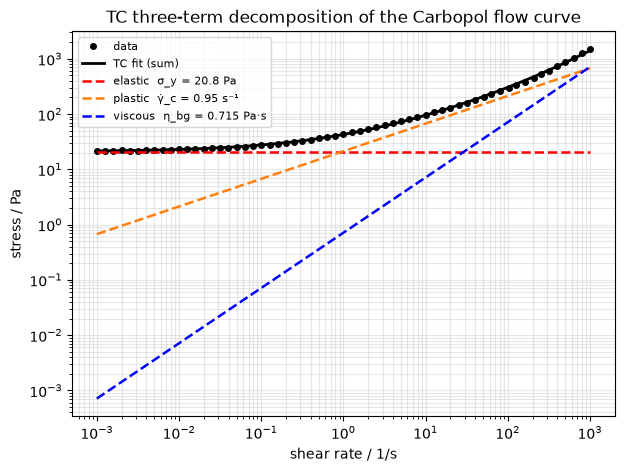

In [24]:
yield_stress = tc_parameters["sigma_y"]
critical_shear_rate = tc_parameters["gamma_dot_c"]
background_viscosity = tc_parameters["eta_bg"]

elastic_stress = np.full_like(shear_rate_grid, yield_stress)
plastic_stress = yield_stress * np.sqrt(
    shear_rate_grid / critical_shear_rate
)
viscous_stress = background_viscosity * shear_rate_grid

fig, ax_stress_components = plt.subplots(figsize=(7, 5))
ax_stress_components.loglog(
    shear_rate,
    stress,
    "ko",
    ms=4,
    label="data",
)
ax_stress_components.loglog(
    shear_rate_grid,
    tc_stress_fit,
    "k-",
    lw=2,
    label="TC fit (sum)",
)
ax_stress_components.loglog(
    shear_rate_grid,
    elastic_stress,
    "r--",
    lw=1.8,
    label=f"elastic  σ_y = {yield_stress:.1f} Pa",
)
ax_stress_components.loglog(
    shear_rate_grid,
    plastic_stress,
    "--",
    color="tab:orange",
    lw=1.8,
    label=f"plastic  γ̇_c = {critical_shear_rate:.2f} s⁻¹",
)
ax_stress_components.loglog(
    shear_rate_grid,
    viscous_stress,
    "b--",
    lw=1.8,
    label=f"viscous  η_bg = {background_viscosity:.3f} Pa·s",
)
ax_stress_components.set_xlabel("shear rate / 1/s")
ax_stress_components.set_ylabel("stress / Pa")
ax_stress_components.set_title(
    "TC three-term decomposition of the Carbopol flow curve"
)
ax_stress_components.legend(fontsize=8)
ax_stress_components.grid(True, which="both", alpha=0.3)

Which mechanism carries the stress depends on where you look — the *dissipation map*
below shows each term's fraction of the total stress.

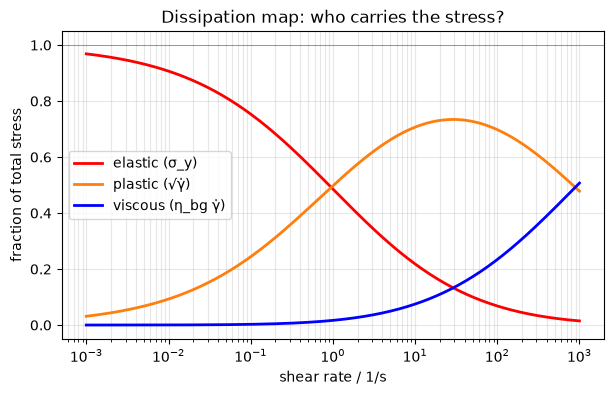

In [25]:
elastic_stress_fraction = elastic_stress / tc_stress_fit
plastic_stress_fraction = plastic_stress / tc_stress_fit
viscous_stress_fraction = viscous_stress / tc_stress_fit

fig, ax_dissipation = plt.subplots(figsize=(7, 4))
ax_dissipation.semilogx(
    shear_rate_grid,
    elastic_stress_fraction,
    "r-",
    lw=2,
    label="elastic (σ_y)",
)
ax_dissipation.semilogx(
    shear_rate_grid,
    plastic_stress_fraction,
    color="tab:orange",
    lw=2,
    label="plastic (√γ̇)",
)
ax_dissipation.semilogx(
    shear_rate_grid,
    viscous_stress_fraction,
    "b-",
    lw=2,
    label="viscous (η_bg γ̇)",
)
ax_dissipation.axhline(1.0, color="k", lw=0.6, alpha=0.4)
ax_dissipation.set_xlabel("shear rate / 1/s")
ax_dissipation.set_ylabel("fraction of total stress")
ax_dissipation.set_title("Dissipation map: who carries the stress?")
ax_dissipation.set_ylim(-0.05, 1.05)
ax_dissipation.legend()
ax_dissipation.grid(True, which="both", alpha=0.3)

## 💡 Takeaway

- 🔴 **Elastic, σ_y = 20.8 Pa** — the rate-independent plateau. The jammed microgel network holds until stress exceeds this; below it, the sample is a solid.
- 🟠 **Plastic, γ̇_c = 0.95 s⁻¹** — the √γ̇ rise from elastoplastic rearrangements (Hébraud–Lequeux / kinetic elastoplastic picture). γ̇_c sets *where* this regime lives.
- 🔵 **Viscous, η_bg = 0.715 Pa·s** — the linear high-shear tail: dissipation through the propylene glycol continuous phase. In water this term would be negligible; in propylene glycol it bends the whole top end of the curve — which is exactly why HB's single exponent fails here.

At rest and low rates the response is almost entirely elastic (the yield stress you feel
when the gel won't pour). Through the middle decades, plastic rearrangements take over.
At the highest rates, the viscous continuous phase dominates. Six decades, three
regimes, three parameters — each one tied to something you could formulate *against*:
raise σ_y with more Carbopol, shift γ̇_c with the microgel softness, tune η_bg with the
solvent.

*Full write-up: the [rheofit case study](https://rheofit.readthedocs.io/en/latest/walkthrough.html)
(Caggioni, Trappe & Spicer, J. Rheol. **64**, 413–422 (2020), doi:10.1122/1.5120633).*